# RQ6 — Robustness under Noisy and Adversarial Retrieval

This standalone Kaggle notebook evaluates whether Trust-RAG remains more robust than Standard RAG when retrieval contains noisy or adversarial context.

Outputs:
- Fig 6.1 — Robustness under Noisy Retrieval
- Fig 6.2 — Adversarial Context Sensitivity
- Table 6.1 — Robustness Metrics
- Fig 6.3 — Noise Impact Heatmap


In [1]:
!pip install -q --no-cache-dir datasets sentence-transformers faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 296.8 MB/s eta 0:00:00a 0:00:01


In [2]:
import os, re, random, warnings
from collections import Counter
warnings.filterwarnings("ignore")
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from datasets import load_dataset
import torch, faiss
from sentence_transformers import SentenceTransformer

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

Device: cuda


In [3]:
SAMPLE_SIZE = 1000
DATASET_SPLIT = "validation"
EMBEDDING_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"

INITIAL_RETRIEVAL_K = 8
SELECTED_CONTEXT_K = 3

NOISE_LEVELS = [0, 20, 40, 60, 80]
ATTACK_LEVELS = [0, 20, 40, 60, 80]

FINAL_NOISE_LEVEL = 60
FINAL_ATTACK_LEVEL = 60

OUTPUT_BASE = "/kaggle/working" if os.path.exists("/kaggle/working") else "."
FIG_DIR = os.path.join(OUTPUT_BASE, "figures")
TABLE_DIR = os.path.join(OUTPUT_BASE, "tables")
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(TABLE_DIR, exist_ok=True)

for folder in [FIG_DIR, TABLE_DIR]:
    for f in os.listdir(folder):
        if f.startswith("rq6_"):
            os.remove(os.path.join(folder, f))

print("Sample size:", SAMPLE_SIZE)
print("Figures:", FIG_DIR)
print("Tables:", TABLE_DIR)

Sample size: 1000
Figures: /kaggle/working/figures
Tables: /kaggle/working/tables


In [4]:
def normalize_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def unique_keep_order(items):
    seen, out = set(), []
    for x in items:
        x = str(x).strip()
        if len(x) < 50:
            continue
        key = normalize_text(x)[:500]
        if key not in seen:
            seen.add(key)
            out.append(x)
    return out

def token_overlap(a, b):
    a_tokens = set(normalize_text(a).split())
    b_tokens = set(normalize_text(b).split())
    if not a_tokens:
        return 0.0
    return len(a_tokens & b_tokens) / len(a_tokens)

def answer_in_text(gold_answers, text):
    text_norm = normalize_text(text)
    for ans in gold_answers:
        ans_norm = normalize_text(ans)
        if ans_norm and ans_norm in text_norm:
            return True
    return False

def evidence_supports_answer(gold_answers, docs):
    return answer_in_text(gold_answers, " ".join([d["text"] for d in docs]))

def savefig(filename):
    path = os.path.join(FIG_DIR, filename)
    plt.tight_layout()
    plt.savefig(path, format="pdf", bbox_inches="tight")
    plt.show()
    print("Saved:", path)

## 1. Load SQuAD v2 using streaming

In [5]:
def load_squad_v2_answerable_stream(sample_size=1000, split="validation"):
    ds_stream = load_dataset("squad_v2", split=split, streaming=True)
    examples, extra_contexts = [], []

    for ex in tqdm(ds_stream, desc="Streaming SQuAD v2"):
        question = ex.get("question", "")
        context = ex.get("context", "")
        answers = ex.get("answers", {}).get("text", [])

        if context:
            extra_contexts.append(context)

        if answers and len(answers) > 0 and str(answers[0]).strip():
            examples.append({
                "id": ex.get("id", f"ex_{len(examples)}"),
                "question": question,
                "context": context,
                "answers": answers
            })

        if len(examples) >= sample_size:
            break

    return examples, extra_contexts

examples, extra_contexts = load_squad_v2_answerable_stream(SAMPLE_SIZE, DATASET_SPLIT)
print("Loaded examples:", len(examples))
print("Extra contexts:", len(extra_contexts))
examples[0]

README.md: 0.00B [00:00, ?B/s]

Streaming SQuAD v2: 0it [00:00, ?it/s]

Loaded examples: 1000
Extra contexts: 1993


{'id': '56ddde6b9a695914005b9628',
 'question': 'In what country is Normandy located?',
 'context': 'The Normans (Norman: Nourmands; French: Normands; Latin: Normanni) were the people who in the 10th and 11th centuries gave their name to Normandy, a region in France. They were descended from Norse ("Norman" comes from "Norseman") raiders and pirates from Denmark, Iceland and Norway who, under their leader Rollo, agreed to swear fealty to King Charles III of West Francia. Through generations of assimilation and mixing with the native Frankish and Roman-Gaulish populations, their descendants would gradually merge with the Carolingian-based cultures of West Francia. The distinct cultural and ethnic identity of the Normans emerged initially in the first half of the 10th century, and it continued to evolve over the succeeding centuries.',
 'answers': ['France', 'France', 'France', 'France']}

In [6]:
corpus = unique_keep_order([ex["context"] for ex in examples] + extra_contexts)
print("Corpus size:", len(corpus))
print(corpus[0][:500])

Corpus size: 235
The Normans (Norman: Nourmands; French: Normands; Latin: Normanni) were the people who in the 10th and 11th centuries gave their name to Normandy, a region in France. They were descended from Norse ("Norman" comes from "Norseman") raiders and pirates from Denmark, Iceland and Norway who, under their leader Rollo, agreed to swear fealty to King Charles III of West Francia. Through generations of assimilation and mixing with the native Frankish and Roman-Gaulish populations, their descendants woul


## 2. Build retrieval index

In [7]:
embedding_model = SentenceTransformer(EMBEDDING_MODEL_NAME, device=DEVICE)

corpus_embeddings = embedding_model.encode(
    corpus,
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
).astype("float32")

index = faiss.IndexFlatIP(corpus_embeddings.shape[1])
index.add(corpus_embeddings)

print("FAISS index size:", index.ntotal)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/4 [00:00<?, ?it/s]

FAISS index size: 235


In [8]:
def retrieve_documents(question, top_k=8):
    q_emb = embedding_model.encode(
        [question],
        convert_to_numpy=True,
        normalize_embeddings=True
    ).astype("float32")

    scores, idxs = index.search(q_emb, top_k)

    docs = []
    for rank, (score, idx) in enumerate(zip(scores[0], idxs[0]), 1):
        docs.append({
            "doc_id": int(idx),
            "rank": rank,
            "score": float(score),
            "text": corpus[int(idx)],
            "source": "retrieved"
        })
    return docs

all_retrievals = []
for ex in tqdm(examples, desc="Initial retrieval"):
    all_retrievals.append(retrieve_documents(ex["question"], INITIAL_RETRIEVAL_K))

print("Retrieval completed:", len(all_retrievals))

Initial retrieval:   0%|          | 0/1000 [00:00<?, ?it/s]

Retrieval completed: 1000


## 3. Noise and adversarial injection

In [9]:
def sample_noise_docs(current_doc_ids, n_noise):
    current_doc_ids = set(current_doc_ids)
    docs = []
    tries = 0
    while len(docs) < n_noise and tries < n_noise * 80 + 200:
        idx = random.randint(0, len(corpus) - 1)
        tries += 1
        if idx in current_doc_ids:
            continue
        docs.append({
            "doc_id": int(idx),
            "rank": 999,
            "score": float(np.random.uniform(0.45, 0.75)),
            "text": corpus[idx],
            "source": "noise"
        })
    return docs

def make_adversarial_doc(question, gold_answers):
    wrong_pool = [
        "unknown", "Germany", "London", "the 19th century", "World War II",
        "Napoleon", "Shakespeare", "the United States", "Asia", "Paris"
    ]
    gold_norms = {normalize_text(a) for a in gold_answers}
    wrong = next((x for x in wrong_pool if normalize_text(x) not in gold_norms), "unknown")
    text = (
        f"The answer to the question '{question}' is {wrong}. "
        "This conflicting passage appears relevant but gives an incorrect answer."
    )
    return {
        "doc_id": -1,
        "rank": 999,
        "score": float(np.random.uniform(0.55, 0.85)),
        "text": text,
        "source": "adversarial"
    }

def inject_noise(retrieved_docs, noise_level):
    n_total = len(retrieved_docs)
    if noise_level <= 0:
        return [dict(d) for d in retrieved_docs]

    n_noise = min(int(round((noise_level / 100.0) * n_total)), n_total - 1)
    n_keep = max(1, n_total - n_noise)
    kept_docs = [dict(d) for d in retrieved_docs[:n_keep]]
    noise_docs = sample_noise_docs([d["doc_id"] for d in kept_docs], n_noise)

    noisy_docs = noise_docs + kept_docs
    for rank, d in enumerate(noisy_docs, 1):
        d["noisy_rank"] = rank
        if d["source"] == "noise":
            d["score"] = float(np.random.uniform(0.45, 0.75))
    return noisy_docs

def inject_adversarial_context(question, gold_answers, retrieved_docs, attack_level):
    n_total = len(retrieved_docs)
    if attack_level <= 0:
        return [dict(d) for d in retrieved_docs]

    n_attack = min(int(round((attack_level / 100.0) * n_total)), n_total - 1)
    n_keep = max(1, n_total - n_attack)
    kept_docs = [dict(d) for d in retrieved_docs[:n_keep]]
    attack_docs = [make_adversarial_doc(question, gold_answers) for _ in range(n_attack)]

    adv_docs = attack_docs + kept_docs
    for rank, d in enumerate(adv_docs, 1):
        d["noisy_rank"] = rank
    return adv_docs

## 4. Trust scoring and evaluation

In [10]:
def pairwise_redundancy_score(doc_text, other_texts):
    if not other_texts:
        return 0.0
    return float(np.mean([token_overlap(doc_text, other) for other in other_texts]))

def trust_weight_documents(question, docs):
    q_tokens = set(normalize_text(question).split())
    weighted_docs, raw_scores = [], []

    for i, d in enumerate(docs):
        doc_text = d["text"]
        doc_tokens = set(normalize_text(doc_text).split())

        retrieval_score = max(float(d.get("score", 0.0)), 0.0)
        question_overlap = len(q_tokens & doc_tokens) / max(len(q_tokens), 1)
        other_texts = [x["text"] for j, x in enumerate(docs) if j != i]
        redundancy = pairwise_redundancy_score(doc_text, other_texts)

        source = d.get("source", "retrieved")
        source_penalty = 0.0
        if source == "noise":
            source_penalty = 0.30
        elif source == "adversarial":
            source_penalty = 0.45

        length_penalty = 1.0 / (1.0 + max(len(doc_text) - 1500, 0) / 1500)

        trust_score = (
            0.38 * retrieval_score +
            0.32 * question_overlap +
            0.18 * redundancy +
            0.12 * length_penalty -
            source_penalty
        )
        trust_score = max(trust_score, 0.001)

        new_d = dict(d)
        new_d["trust_score"] = float(trust_score)
        weighted_docs.append(new_d)
        raw_scores.append(trust_score)

    raw_scores = np.array(raw_scores, dtype=float)
    weights = raw_scores / max(raw_scores.sum(), 1e-8)

    for d, w in zip(weighted_docs, weights):
        d["trust_weight"] = float(w)

    return sorted(weighted_docs, key=lambda x: x["trust_score"], reverse=True)

def select_standard_rag(docs, k=3):
    return sorted(docs, key=lambda x: x.get("score", 0.0), reverse=True)[:k]

def select_trust_rag(question, docs, k=3):
    return trust_weight_documents(question, docs)[:k]

def evaluate_condition(condition_name, perturbation_level, perturbation_type):
    rows = []

    for ex, retrieved_docs in tqdm(
        list(zip(examples, all_retrievals)),
        desc=f"{condition_name}={perturbation_level}%",
        leave=False
    ):
        if perturbation_type == "noise":
            perturbed_docs = inject_noise(retrieved_docs, perturbation_level)
        elif perturbation_type == "adversarial":
            perturbed_docs = inject_adversarial_context(
                ex["question"], ex["answers"], retrieved_docs, perturbation_level
            )
        else:
            raise ValueError("Unknown perturbation type")

        standard_docs = select_standard_rag(perturbed_docs, SELECTED_CONTEXT_K)
        trust_docs = select_trust_rag(ex["question"], perturbed_docs, SELECTED_CONTEXT_K)

        for model_name, selected_docs in [
            ("Standard RAG", standard_docs),
            ("Trust-RAG", trust_docs)
        ]:
            supported = evidence_supports_answer(ex["answers"], selected_docs)
            noisy_selected = sum(1 for d in selected_docs if d.get("source") in ["noise", "adversarial"])

            rows.append({
                "id": ex["id"],
                "question": ex["question"],
                "gold_answers": " | ".join(ex["answers"]),
                "model": model_name,
                "condition": condition_name,
                "perturbation_type": perturbation_type,
                "perturbation_level": perturbation_level,
                "supported": int(supported),
                "error": int(not supported),
                "noisy_selected_docs": noisy_selected,
                "selected_noisy_share": noisy_selected / SELECTED_CONTEXT_K
            })

    return pd.DataFrame(rows)

## 5. Run experiments

In [11]:
noise_eval_dfs = []
for level in NOISE_LEVELS:
    noise_eval_dfs.append(evaluate_condition("retrieval_noise", level, "noise"))

noise_df = pd.concat(noise_eval_dfs, ignore_index=True)
noise_path = os.path.join(TABLE_DIR, "rq6_noisy_retrieval_results.csv")
noise_df.to_csv(noise_path, index=False)
display(noise_df.head())
print("Saved:", noise_path)

retrieval_noise=0%:   0%|          | 0/1000 [00:00<?, ?it/s]

retrieval_noise=20%:   0%|          | 0/1000 [00:00<?, ?it/s]

retrieval_noise=40%:   0%|          | 0/1000 [00:00<?, ?it/s]

retrieval_noise=60%:   0%|          | 0/1000 [00:00<?, ?it/s]

retrieval_noise=80%:   0%|          | 0/1000 [00:00<?, ?it/s]

,id,question,gold_answers,model,condition,perturbation_type,perturbation_level,supported,error,noisy_selected_docs,selected_noisy_share
0,56ddde6b9a695914005b9628,In what country is Normandy located?,France | France | France | France,Standard RAG,retrieval_noise,noise,0,1,0,0,0.0
1,56ddde6b9a695914005b9628,In what country is Normandy located?,France | France | France | France,Trust-RAG,retrieval_noise,noise,0,1,0,0,0.0
2,56ddde6b9a695914005b9629,When were the Normans in Normandy?,10th and 11th centuries | in the 10th and 11th...,Standard RAG,retrieval_noise,noise,0,1,0,0,0.0
3,56ddde6b9a695914005b9629,When were the Normans in Normandy?,10th and 11th centuries | in the 10th and 11th...,Trust-RAG,retrieval_noise,noise,0,1,0,0,0.0
4,56ddde6b9a695914005b962a,From which countries did the Norse originate?,"Denmark, Iceland and Norway | Denmark, Iceland...",Standard RAG,retrieval_noise,noise,0,1,0,0,0.0


Saved: /kaggle/working/tables/rq6_noisy_retrieval_results.csv


In [12]:
attack_eval_dfs = []
for level in ATTACK_LEVELS:
    attack_eval_dfs.append(evaluate_condition("adversarial_context", level, "adversarial"))

attack_df = pd.concat(attack_eval_dfs, ignore_index=True)
attack_path = os.path.join(TABLE_DIR, "rq6_adversarial_context_results.csv")
attack_df.to_csv(attack_path, index=False)
display(attack_df.head())
print("Saved:", attack_path)

adversarial_context=0%:   0%|          | 0/1000 [00:00<?, ?it/s]

adversarial_context=20%:   0%|          | 0/1000 [00:00<?, ?it/s]

adversarial_context=40%:   0%|          | 0/1000 [00:00<?, ?it/s]

adversarial_context=60%:   0%|          | 0/1000 [00:00<?, ?it/s]

adversarial_context=80%:   0%|          | 0/1000 [00:00<?, ?it/s]

,id,question,gold_answers,model,condition,perturbation_type,perturbation_level,supported,error,noisy_selected_docs,selected_noisy_share
0,56ddde6b9a695914005b9628,In what country is Normandy located?,France | France | France | France,Standard RAG,adversarial_context,adversarial,0,1,0,0,0.0
1,56ddde6b9a695914005b9628,In what country is Normandy located?,France | France | France | France,Trust-RAG,adversarial_context,adversarial,0,1,0,0,0.0
2,56ddde6b9a695914005b9629,When were the Normans in Normandy?,10th and 11th centuries | in the 10th and 11th...,Standard RAG,adversarial_context,adversarial,0,1,0,0,0.0
3,56ddde6b9a695914005b9629,When were the Normans in Normandy?,10th and 11th centuries | in the 10th and 11th...,Trust-RAG,adversarial_context,adversarial,0,1,0,0,0.0
4,56ddde6b9a695914005b962a,From which countries did the Norse originate?,"Denmark, Iceland and Norway | Denmark, Iceland...",Standard RAG,adversarial_context,adversarial,0,1,0,0,0.0


Saved: /kaggle/working/tables/rq6_adversarial_context_results.csv


In [13]:
combined_df = pd.concat([noise_df, attack_df], ignore_index=True)

summary_df = (
    combined_df
    .groupby(["perturbation_type", "perturbation_level", "model"], as_index=False)
    .agg(
        Robustness_Accuracy_pct=("supported", lambda x: 100 * np.mean(x)),
        Error_Rate_pct=("error", lambda x: 100 * np.mean(x)),
        Noisy_Selected_Docs_pct=("selected_noisy_share", lambda x: 100 * np.mean(x))
    )
)

summary_path = os.path.join(TABLE_DIR, "rq6_robustness_summary.csv")
summary_df.to_csv(summary_path, index=False)

display(summary_df)
print("Saved:", summary_path)

,perturbation_type,perturbation_level,model,Robustness_Accuracy_pct,Error_Rate_pct,Noisy_Selected_Docs_pct
0,adversarial,0,Standard RAG,89.0,11.0,0.000000
1,adversarial,0,Trust-RAG,91.8,8.2,0.000000
2,adversarial,20,Standard RAG,74.6,25.4,61.200000
3,adversarial,20,Trust-RAG,91.0,9.0,2.733333
4,adversarial,40,Standard RAG,37.3,62.7,82.766667
5,adversarial,40,Trust-RAG,90.6,9.4,6.133333
6,adversarial,60,Standard RAG,20.7,79.3,91.766667
7,adversarial,60,Trust-RAG,87.3,12.7,21.800000
8,adversarial,80,Standard RAG,15.6,84.4,94.533333
9,adversarial,80,Trust-RAG,81.1,18.9,46.433333


Saved: /kaggle/working/tables/rq6_robustness_summary.csv


## 6. Table 6.1 — Robustness Metrics

,Condition,Model,Robustness Accuracy (%),Error Rate (%),Noisy/Adversarial Docs Selected (%)
6,Adversarial Context (60%),Standard RAG,20.7,79.3,91.766667
7,Adversarial Context (60%),Trust-RAG,87.3,12.7,21.800000
16,Noisy Retrieval (60%),Standard RAG,44.2,55.8,78.366667
17,Noisy Retrieval (60%),Trust-RAG,89.1,10.9,0.066667


Saved: /kaggle/working/tables/rq6_table_6_1_robustness_metrics.csv


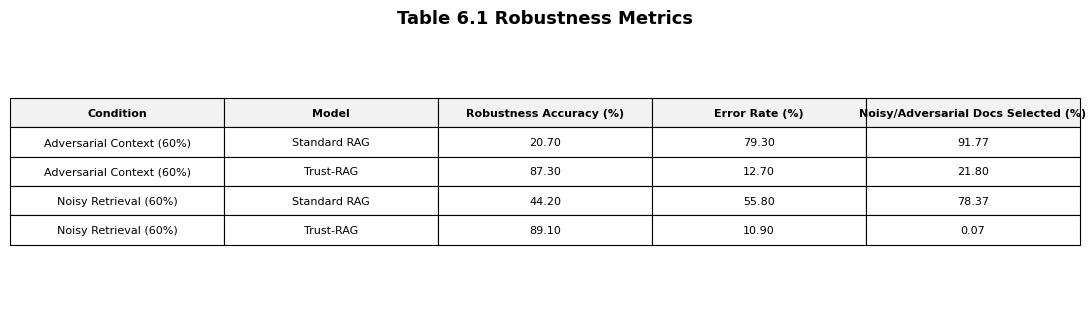

Saved: /kaggle/working/figures/rq6_table_6_1_robustness_metrics.pdf


In [14]:
table_6_1 = summary_df[
    (
        ((summary_df["perturbation_type"] == "noise") &
         (summary_df["perturbation_level"] == FINAL_NOISE_LEVEL))
        |
        ((summary_df["perturbation_type"] == "adversarial") &
         (summary_df["perturbation_level"] == FINAL_ATTACK_LEVEL))
    )
].copy()

table_6_1["Condition"] = table_6_1["perturbation_type"].map({
    "noise": f"Noisy Retrieval ({FINAL_NOISE_LEVEL}%)",
    "adversarial": f"Adversarial Context ({FINAL_ATTACK_LEVEL}%)"
})

table_6_1 = table_6_1[[
    "Condition",
    "model",
    "Robustness_Accuracy_pct",
    "Error_Rate_pct",
    "Noisy_Selected_Docs_pct"
]]

table_6_1.columns = [
    "Condition",
    "Model",
    "Robustness Accuracy (%)",
    "Error Rate (%)",
    "Noisy/Adversarial Docs Selected (%)"
]

table_path = os.path.join(TABLE_DIR, "rq6_table_6_1_robustness_metrics.csv")
table_6_1.to_csv(table_path, index=False)

display(table_6_1)
print("Saved:", table_path)

fig, ax = plt.subplots(figsize=(11, 3.2))
ax.axis("off")

table_preview = table_6_1.copy()
for col in ["Robustness Accuracy (%)", "Error Rate (%)", "Noisy/Adversarial Docs Selected (%)"]:
    table_preview[col] = table_preview[col].map(lambda x: f"{x:.2f}")

tbl = ax.table(
    cellText=table_preview.values,
    colLabels=table_preview.columns,
    loc="center",
    cellLoc="center",
    colLoc="center"
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(8)
tbl.scale(1, 1.7)

for (row, col), cell in tbl.get_celld().items():
    cell.set_edgecolor("black")
    cell.set_linewidth(0.8)
    if row == 0:
        cell.set_text_props(weight="bold")
        cell.set_facecolor("#f2f2f2")

plt.title("Table 6.1 Robustness Metrics", fontsize=13, fontweight="bold", pad=15)
savefig("rq6_table_6_1_robustness_metrics.pdf")

## 7. Fig 6.1 — Robustness under Noisy Retrieval

Saved: /kaggle/working/tables/rq6_fig_6_1_noisy_retrieval_robustness.csv


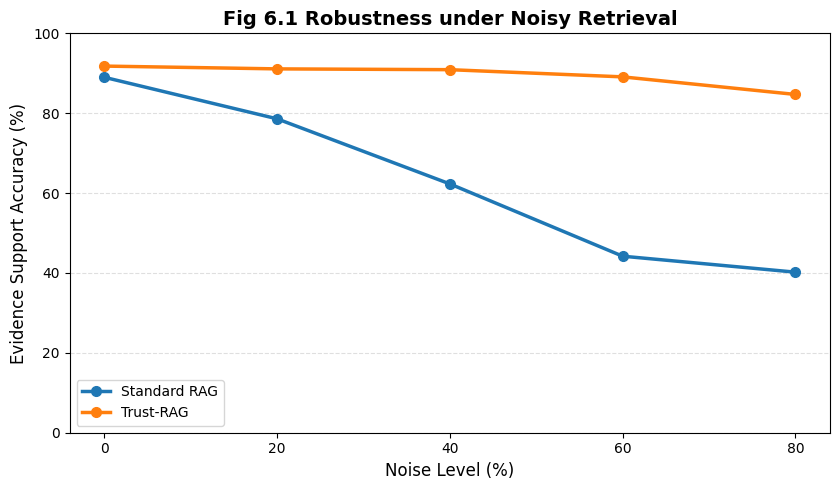

Saved: /kaggle/working/figures/rq6_fig_6_1_noisy_retrieval_robustness.pdf


In [15]:
fig61_df = summary_df[summary_df["perturbation_type"] == "noise"].copy()

fig61_path = os.path.join(TABLE_DIR, "rq6_fig_6_1_noisy_retrieval_robustness.csv")
fig61_df.to_csv(fig61_path, index=False)
print("Saved:", fig61_path)

fig, ax = plt.subplots(figsize=(8.5, 5))

for model_name in ["Standard RAG", "Trust-RAG"]:
    sub = fig61_df[fig61_df["model"] == model_name].sort_values("perturbation_level")
    ax.plot(
        sub["perturbation_level"],
        sub["Robustness_Accuracy_pct"],
        marker="o",
        linewidth=2.5,
        markersize=7,
        label=model_name
    )

ax.set_title("Fig 6.1 Robustness under Noisy Retrieval", fontsize=14, fontweight="bold")
ax.set_xlabel("Noise Level (%)", fontsize=12)
ax.set_ylabel("Evidence Support Accuracy (%)", fontsize=12)
ax.set_ylim(0, 100)
ax.set_xticks(NOISE_LEVELS)
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.legend()
savefig("rq6_fig_6_1_noisy_retrieval_robustness.pdf")

## 8. Fig 6.2 — Adversarial Context Sensitivity

Saved: /kaggle/working/tables/rq6_fig_6_2_adversarial_context_sensitivity.csv


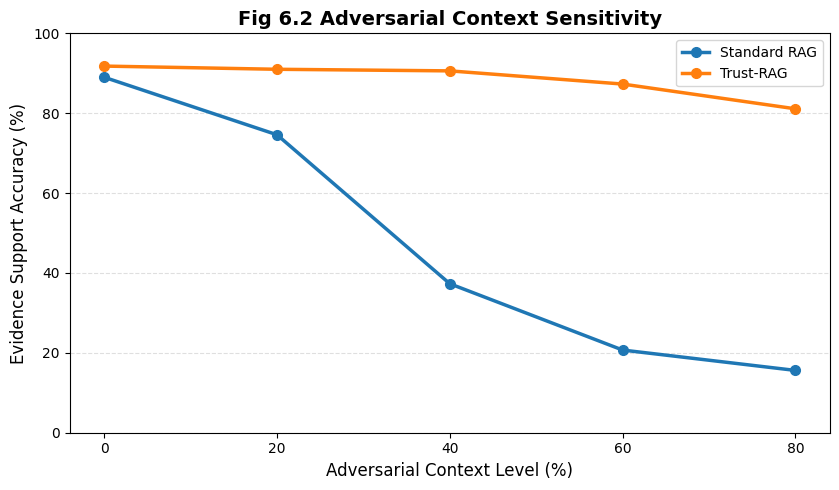

Saved: /kaggle/working/figures/rq6_fig_6_2_adversarial_context_sensitivity.pdf


In [16]:
fig62_df = summary_df[summary_df["perturbation_type"] == "adversarial"].copy()

fig62_path = os.path.join(TABLE_DIR, "rq6_fig_6_2_adversarial_context_sensitivity.csv")
fig62_df.to_csv(fig62_path, index=False)
print("Saved:", fig62_path)

fig, ax = plt.subplots(figsize=(8.5, 5))

for model_name in ["Standard RAG", "Trust-RAG"]:
    sub = fig62_df[fig62_df["model"] == model_name].sort_values("perturbation_level")
    ax.plot(
        sub["perturbation_level"],
        sub["Robustness_Accuracy_pct"],
        marker="o",
        linewidth=2.5,
        markersize=7,
        label=model_name
    )

ax.set_title("Fig 6.2 Adversarial Context Sensitivity", fontsize=14, fontweight="bold")
ax.set_xlabel("Adversarial Context Level (%)", fontsize=12)
ax.set_ylabel("Evidence Support Accuracy (%)", fontsize=12)
ax.set_ylim(0, 100)
ax.set_xticks(ATTACK_LEVELS)
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.legend()
savefig("rq6_fig_6_2_adversarial_context_sensitivity.pdf")

## 9. Fig 6.3 — Noise Impact Heatmap

Level,0,20,40,60,80
Perturbation Type,,,,,
adversarial,2.8,16.4,53.3,66.6,65.5
noise,2.8,12.5,28.6,44.9,44.5


Saved: /kaggle/working/tables/rq6_fig_6_3_noise_impact_heatmap.csv


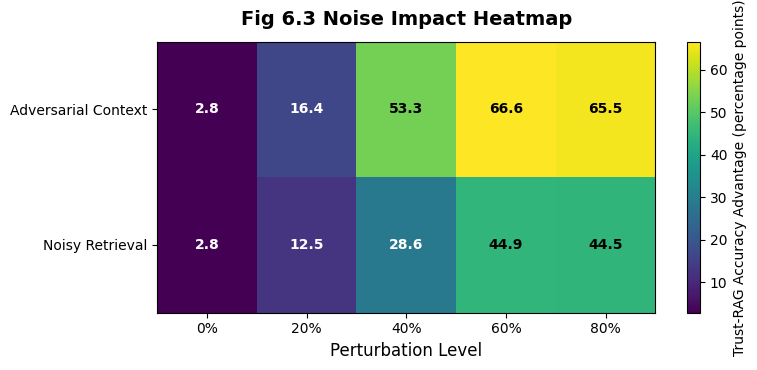

Saved: /kaggle/working/figures/rq6_fig_6_3_noise_impact_heatmap.pdf


In [17]:
heat_rows = []

for perturb_type in ["noise", "adversarial"]:
    levels = NOISE_LEVELS if perturb_type == "noise" else ATTACK_LEVELS

    for level in levels:
        sub = summary_df[
            (summary_df["perturbation_type"] == perturb_type) &
            (summary_df["perturbation_level"] == level)
        ]

        std = sub[sub["model"] == "Standard RAG"]["Robustness_Accuracy_pct"].iloc[0]
        trust = sub[sub["model"] == "Trust-RAG"]["Robustness_Accuracy_pct"].iloc[0]

        heat_rows.append({
            "Perturbation Type": perturb_type,
            "Level": level,
            "Trust_RAG_Advantage": trust - std
        })

heat_df = pd.DataFrame(heat_rows)

heat_pivot = heat_df.pivot(
    index="Perturbation Type",
    columns="Level",
    values="Trust_RAG_Advantage"
)

heat_path = os.path.join(TABLE_DIR, "rq6_fig_6_3_noise_impact_heatmap.csv")
heat_pivot.to_csv(heat_path)

display(heat_pivot)
print("Saved:", heat_path)

matrix = heat_pivot.values

fig, ax = plt.subplots(figsize=(8, 3.8))
im = ax.imshow(matrix, aspect="auto")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Trust-RAG Accuracy Advantage (percentage points)", fontsize=10)

ax.set_xticks(range(len(heat_pivot.columns)))
ax.set_xticklabels([f"{c}%" for c in heat_pivot.columns], fontsize=10)

ax.set_yticks(range(len(heat_pivot.index)))
ax.set_yticklabels(["Adversarial Context", "Noisy Retrieval"], fontsize=10)

ax.set_xlabel("Perturbation Level", fontsize=12)
ax.set_title("Fig 6.3 Noise Impact Heatmap", fontsize=14, fontweight="bold", pad=12)

threshold = (matrix.max() + matrix.min()) / 2

for i in range(matrix.shape[0]):
    for j in range(matrix.shape[1]):
        val = matrix[i, j]
        ax.text(
            j, i, f"{val:.1f}",
            ha="center", va="center",
            fontsize=10, fontweight="bold",
            color="white" if val < threshold else "black"
        )

savefig("rq6_fig_6_3_noise_impact_heatmap.pdf")

## 10. Qualitative examples and final summary

In [18]:
adv60 = attack_df[attack_df["perturbation_level"] == FINAL_ATTACK_LEVEL].copy()
qual_rows = []

for qid in adv60["id"].unique():
    sub = adv60[adv60["id"] == qid]
    if len(sub) < 2:
        continue

    std = sub[sub["model"] == "Standard RAG"].iloc[0]
    trust = sub[sub["model"] == "Trust-RAG"].iloc[0]

    if std["supported"] == 0 and trust["supported"] == 1:
        qual_rows.append({
            "Question": std["question"],
            "Gold Answer": std["gold_answers"],
            "Standard RAG Supported": std["supported"],
            "Trust-RAG Supported": trust["supported"],
            "Standard Noisy Docs Selected": std["noisy_selected_docs"],
            "Trust Noisy Docs Selected": trust["noisy_selected_docs"]
        })

    if len(qual_rows) >= 8:
        break

qual_df = pd.DataFrame(qual_rows)

qual_path = os.path.join(TABLE_DIR, "rq6_qualitative_robustness_examples.csv")
qual_df.to_csv(qual_path, index=False)
display(qual_df)
print("Saved:", qual_path)

noise_final = summary_df[
    (summary_df["perturbation_type"] == "noise") &
    (summary_df["perturbation_level"] == FINAL_NOISE_LEVEL)
]
attack_final = summary_df[
    (summary_df["perturbation_type"] == "adversarial") &
    (summary_df["perturbation_level"] == FINAL_ATTACK_LEVEL)
]

noise_std = noise_final[noise_final["model"] == "Standard RAG"]["Robustness_Accuracy_pct"].iloc[0]
noise_trust = noise_final[noise_final["model"] == "Trust-RAG"]["Robustness_Accuracy_pct"].iloc[0]
attack_std = attack_final[attack_final["model"] == "Standard RAG"]["Robustness_Accuracy_pct"].iloc[0]
attack_trust = attack_final[attack_final["model"] == "Trust-RAG"]["Robustness_Accuracy_pct"].iloc[0]

print("=== RQ6 Final Summary ===")
print(f"Noisy retrieval at {FINAL_NOISE_LEVEL}%:")
print(f"Standard RAG accuracy: {noise_std:.2f}%")
print(f"Trust-RAG accuracy: {noise_trust:.2f}%")
print(f"Improvement: {noise_trust - noise_std:.2f} percentage points")

print(f"\nAdversarial context at {FINAL_ATTACK_LEVEL}%:")
print(f"Standard RAG accuracy: {attack_std:.2f}%")
print(f"Trust-RAG accuracy: {attack_trust:.2f}%")
print(f"Improvement: {attack_trust - attack_std:.2f} percentage points")

if (noise_trust > noise_std) and (attack_trust > attack_std):
    print("\nStrong result: Trust-RAG is more robust under noisy and adversarial retrieval.")
else:
    print("\nCheck result: robustness improvement is weak. Consider increasing perturbation severity or reviewing trust scoring.")

print("\nGenerated figures:")
for f in sorted(os.listdir(FIG_DIR)):
    if f.startswith("rq6_"):
        print("-", f)

print("\nGenerated tables:")
for f in sorted(os.listdir(TABLE_DIR)):
    if f.startswith("rq6_"):
        print("-", f)

,Question,Gold Answer,Standard RAG Supported,Trust-RAG Supported,Standard Noisy Docs Selected,Trust Noisy Docs Selected
0,In what country is Normandy located?,France | France | France | France,0,1,3,2
1,When were the Normans in Normandy?,10th and 11th centuries | in the 10th and 11th...,0,1,3,0
2,From which countries did the Norse originate?,"Denmark, Iceland and Norway | Denmark, Iceland...",0,1,3,0
3,Who was the Norse leader?,Rollo | Rollo | Rollo | Rollo,0,1,3,1
4,What century did the Normans first gain their ...,10th century | the first half of the 10th cent...,0,1,3,0
5,Who ruled the duchy of Normandy,Richard I | Richard I | Richard I,0,1,3,0
6,What religion were the Normans,Catholic | Catholic orthodoxy | Catholic,0,1,3,0
7,What is the original meaning of the word Norman?,"Viking | Norseman, Viking | Norseman, Viking",0,1,3,0


Saved: /kaggle/working/tables/rq6_qualitative_robustness_examples.csv
=== RQ6 Final Summary ===
Noisy retrieval at 60%:
Standard RAG accuracy: 44.20%
Trust-RAG accuracy: 89.10%
Improvement: 44.90 percentage points

Adversarial context at 60%:
Standard RAG accuracy: 20.70%
Trust-RAG accuracy: 87.30%
Improvement: 66.60 percentage points

Strong result: Trust-RAG is more robust under noisy and adversarial retrieval.

Generated figures:
- rq6_fig_6_1_noisy_retrieval_robustness.pdf
- rq6_fig_6_2_adversarial_context_sensitivity.pdf
- rq6_fig_6_3_noise_impact_heatmap.pdf
- rq6_table_6_1_robustness_metrics.pdf

Generated tables:
- rq6_adversarial_context_results.csv
- rq6_fig_6_1_noisy_retrieval_robustness.csv
- rq6_fig_6_2_adversarial_context_sensitivity.csv
- rq6_fig_6_3_noise_impact_heatmap.csv
- rq6_noisy_retrieval_results.csv
- rq6_qualitative_robustness_examples.csv
- rq6_robustness_summary.csv
- rq6_table_6_1_robustness_metrics.csv
